# Logistic Regression – Sensitivity Analysis

## Objective

The initial logistic regression model identified **deposit type** as the strongest predictor of booking cancellation.

However, exploratory analysis revealed that almost all **Non Refund** reservations in the dataset were cancelled, making deposit type an exceptionally strong predictor.

To evaluate whether the model remains predictive without relying on this variable, a second logistic regression model is developed using the same dataset while excluding **deposit_type** from the feature set.

This sensitivity analysis allows the remaining booking characteristics to be evaluated independently.

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Load Dataset

The cleaned hotel booking dataset is loaded.

Only the **deposit_type** variable is excluded from model training.

In [11]:
df = pd.read_csv("hotel_bookings_cleaned.csv")

print(df.shape)

df.head()

(118559, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,large_group
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,False
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,False
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,False
3,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,False
4,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,0.0,0,Transient,107.0,0,0,Check-Out,2015-07-03,False


# Feature Selection

The same predictors from the original model are retained except for **deposit_type**.

Removing only this feature allows the predictive contribution of the remaining booking characteristics to be evaluated without altering the underlying dataset.

In [13]:
features = [

    "hotel",

    "lead_time",

    "distribution_channel",

    "customer_type",

    "is_repeated_guest",

    "previous_cancellations",

    "previous_bookings_not_canceled",

    "booking_changes",

    "total_of_special_requests",

    "adr"

]

target = "is_canceled"

X = df[features]

y = df[target]

# Train-Test Split

The dataset is divided into training and testing subsets using an 80/20 split.

The same random state as the original model is used to ensure a fair comparison between Model A and Model B.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# Data Preprocessing

Categorical variables are transformed using One-Hot Encoding, while numerical variables are passed through unchanged.

This preprocessing pipeline is identical to the original model, ensuring that the only difference between the two models is the exclusion of the deposit_type feature.

In [17]:
categorical_features = [

    "hotel",

    "distribution_channel",

    "customer_type"

]

numeric_features = [

    "lead_time",

    "is_repeated_guest",

    "previous_cancellations",

    "previous_bookings_not_canceled",

    "booking_changes",

    "total_of_special_requests",

    "adr"

]

preprocessor = ColumnTransformer(

    transformers=[

        (

            "cat",

            OneHotEncoder(drop="first"),

            categorical_features

        )

    ],

    remainder="passthrough"

)

# Logistic Regression Model

A Logistic Regression model is trained using the same modelling approach as the original experiment.

The only difference is that the **deposit_type** feature has been removed from the input variables.

This allows the predictive performance of the remaining booking characteristics to be evaluated independently.

In [20]:
model = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(max_iter=3000))

])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['hotel',
                                                   'distribution_channel',
                                                   'customer_type'])])),
                ('classifier', LogisticRegression(max_iter=3000))])

# Model Evaluation

The model is evaluated using five common classification metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

These metrics will later be compared with the original model to determine the impact of removing the deposit_type feature.

In [22]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred),3))
print("Precision:", round(precision_score(y_test, y_pred),3))
print("Recall   :", round(recall_score(y_test, y_pred),3))
print("F1 Score :", round(f1_score(y_test, y_pred),3))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob),3))

Accuracy : 0.773
Precision: 0.751
Recall   : 0.586
F1 Score : 0.658
ROC AUC  : 0.804


# Feature Importance Analysis

After removing the deposit_type feature, the coefficients of the logistic regression model are examined again.

This analysis identifies which booking characteristics become the strongest predictors of cancellation when deposit policy is excluded from the model.

In [28]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

importance = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": coefficients

})

importance["Odds Ratio"] = np.exp(importance["Coefficient"])

importance["Effect"] = np.where(

    importance["Coefficient"] > 0,

    "Increases Cancellation Risk",

    "Reduces Cancellation Risk"

)

importance["Absolute Coefficient"] = importance["Coefficient"].abs()

importance = importance.sort_values(

    "Absolute Coefficient",

    ascending=False

)

importance

,Feature,Coefficient,Odds Ratio,Effect,Absolute Coefficient
10,remainder__previous_cancellations,3.060122,21.330158,Increases Cancellation Risk,3.060122
6,cat__customer_type_Transient,1.505430,4.506091,Increases Cancellation Risk,1.505430
9,remainder__is_repeated_guest,-0.964029,0.381353,Reduces Cancellation Risk,0.964029
2,cat__distribution_channel_GDS,-0.944503,0.388873,Reduces Cancellation Risk,0.944503
13,remainder__total_of_special_requests,-0.841518,0.431056,Reduces Cancellation Risk,0.841518
1,cat__distribution_channel_Direct,-0.724344,0.484642,Reduces Cancellation Risk,0.724344
11,remainder__previous_bookings_not_canceled,-0.614770,0.540765,Reduces Cancellation Risk,0.614770
12,remainder__booking_changes,-0.506023,0.602888,Reduces Cancellation Risk,0.506023
0,cat__hotel_Resort Hotel,-0.274546,0.759917,Reduces Cancellation Risk,0.274546
3,cat__distribution_channel_TA/TO,0.266868,1.305868,Increases Cancellation Risk,0.266868


In [29]:
bri = pd.DataFrame({
    "Cancellation Probability": y_prob,
    "ML_BRI": ...,
    "Actual Cancellation": y_test
})

In [30]:
bri["ML_BRI"] = (1 - bri["Cancellation Probability"]) * 100

bri["Reliability Level"] = pd.cut(
    bri["ML_BRI"],
    bins=[0,20,40,60,80,100],
    labels=["Very Low","Low","Moderate","High","Excellent"],
    include_lowest=True
)

validation = (
    bri.groupby("Reliability Level")
       .agg(
           Total_Bookings=("ML_BRI","count"),
           Average_BRI=("ML_BRI","mean"),
           Actual_Cancellation_Rate=(
               "Actual Cancellation",
               lambda x: round(x.mean()*100,2)
           )
       )
)

validation

C:\Users\Kompiuteris\AppData\Local\Temp\ipykernel_22212\3430073890.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bri.groupby("Reliability Level")


,Total_Bookings,Average_BRI,Actual_Cancellation_Rate
Reliability Level,,,
Very Low,1794,8.022176,98.49
Low,2730,31.354955,75.46
Moderate,4985,50.407388,46.22
High,6979,70.510317,23.56
Excellent,7224,88.977424,14.66


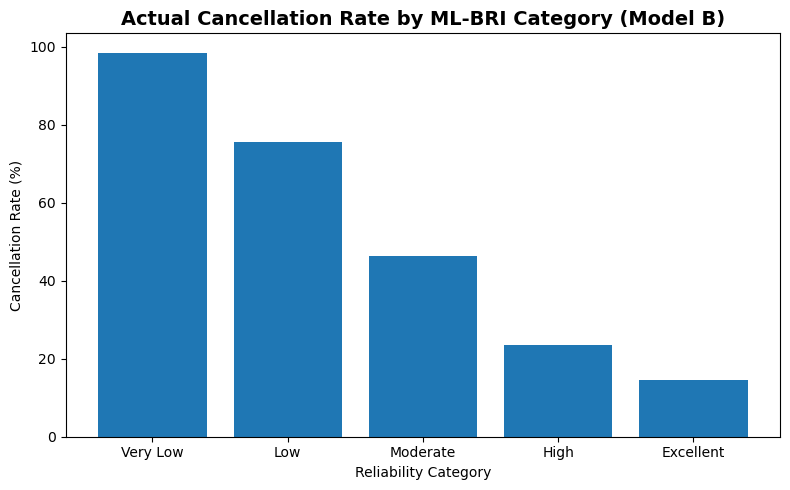

In [31]:
plt.figure(figsize=(8,5))

plt.bar(
    validation.index,
    validation["Actual_Cancellation_Rate"]
)

plt.title(
    "Actual Cancellation Rate by ML-BRI Category (Model B)",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Reliability Category")

plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()

plt.show()

In [39]:
import pandas as pd

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance["Absolute Coefficient"] = importance["Coefficient"].abs()

importance["Feature"] = (
    importance["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
    .str.replace("_", " ")
)

importance = importance.sort_values(
    "Absolute Coefficient",
    ascending=False
)

importance.head(15)

,Feature,Coefficient,Absolute Coefficient
10,previous cancellations,3.060122,3.060122
6,customer type Transient,1.505430,1.505430
9,is repeated guest,-0.964029,0.964029
2,distribution channel GDS,-0.944503,0.944503
13,total of special requests,-0.841518,0.841518
1,distribution channel Direct,-0.724344,0.724344
11,previous bookings not canceled,-0.614770,0.614770
12,booking changes,-0.506023,0.506023
0,hotel Resort Hotel,-0.274546,0.274546
3,distribution channel TA/TO,0.266868,0.266868


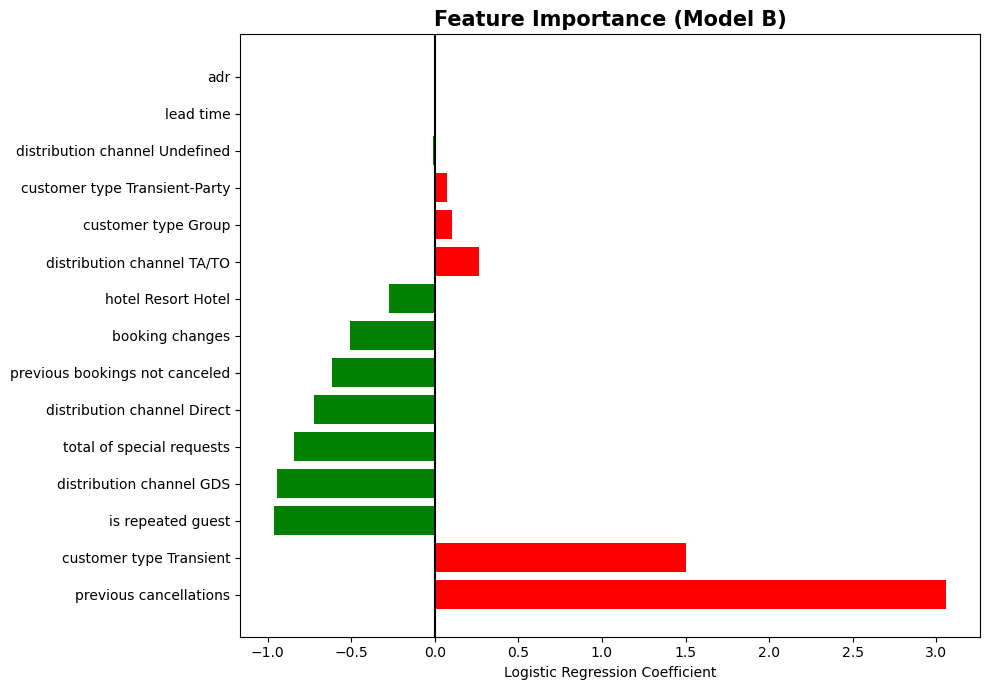

In [43]:
import matplotlib.pyplot as plt

top = importance.head(15).copy()

plt.figure(figsize=(10,7))

colors = [
    "green" if x < 0 else "red"
    for x in top["Coefficient"]
]

plt.barh(
    top["Feature"],
    top["Coefficient"],
    color=colors
)

plt.axvline(0, color="black")

plt.title(
    "Feature Importance (Model B)",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Logistic Regression Coefficient")

plt.tight_layout()

plt.show()

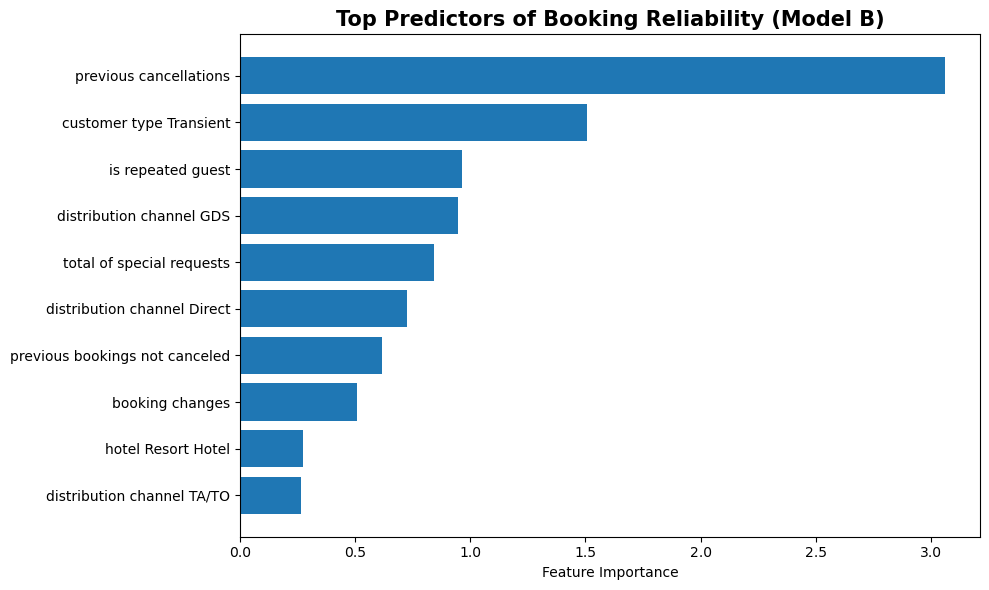

In [41]:
import matplotlib.pyplot as plt

top = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Absolute Coefficient"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top Predictors of Booking Reliability (Model B)",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Feature Importance")

plt.tight_layout()

plt.show()